In [1]:
import yfinance as yf 
import pandas as pd 
import matplotlib.pyplot as plt 

def  fetch_data (): 
    symbols = [ 'HO=F' , 'CL=F' ]   # Futuros de gasóleo de calefacción y petróleo crudo
    df = yf.download(symbols, start= "2015-01-01" , end= "2025-12-31" )[ 'Close' ] 
    df.dropna(inplace= True ) 
    df.columns = [ 'HeatingOil' , 'CrudeOil' ] 
    return df 


In [2]:
df = fetch_data() 
df



[*********************100%***********************]  2 of 2 completed


,HeatingOil,CrudeOil
Date,,
2015-01-02,52.689999,1.7957
2015-01-05,50.040001,1.7492
2015-01-06,47.930000,1.7262
2015-01-07,48.650002,1.6999
2015-01-08,48.790001,1.7110
...,...,...
2025-12-23,58.380001,2.1906
2025-12-24,58.349998,2.1576
2025-12-26,56.740002,2.1070


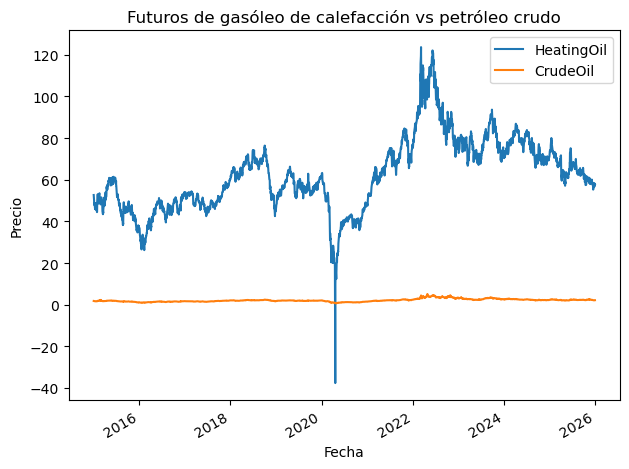

In [3]:

df.plot(title= "Futuros de gasóleo de calefacción vs petróleo crudo" ) 
plt.ylabel( "Precio" ) 
plt.xlabel( "Fecha" ) 
plt.tight_layout() 
plt.show()

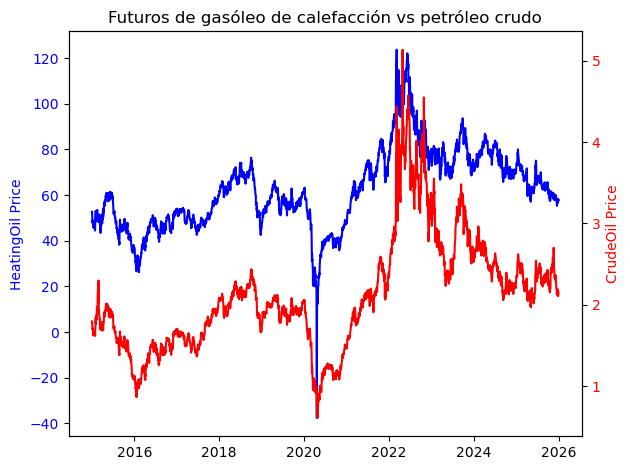

In [4]:
fig, ax1 = plt.subplots()

ax1.plot(df.index, df['HeatingOil'], color='blue', label='HeatingOil')
ax1.set_ylabel('HeatingOil Price', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(df.index, df['CrudeOil'], color='red', label='CrudeOil')
ax2.set_ylabel('CrudeOil Price', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Futuros de gasóleo de calefacción vs petróleo crudo")
plt.xlabel("Fecha")
plt.tight_layout()
plt.show()

In [5]:

from statsmodels.tsa.stattools import adfuller

def adf_summary(df):
    for col in df.columns:
        result = adfuller(df[col])
        print(f"{col} ADF: {result[0]:.4f}, p={result[1]:.4f}")
        result_diff = adfuller(df[col].diff().dropna())
        print(f"{col} ΔADF: {result_diff[0]:.4f}, p={result_diff[1]:.4f}")
adf_summary(df)

HeatingOil ADF: -2.3498, p=0.1564
HeatingOil ΔADF: -9.2100, p=0.0000
CrudeOil ADF: -2.0305, p=0.2734
CrudeOil ΔADF: -13.5352, p=0.0000


In [6]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen 

def  johansen_test ( df ): 
    result = coint_johansen(df, det_order= 0 , k_ar_diff= 1 ) 
    print ( "Estadística de traza:" , result.lr1) 
    print ( "Valores críticos (90%, 95%, 99%):\n" , result.cvt) 
johansen_test(df)

Estadística de traza: [53.95834544  5.82040289]
Valores críticos (90%, 95%, 99%):
 [[13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]


In [7]:
from statsmodels.tsa.vector_ar.vecm import VECM 

vecm_model = VECM(df, k_ar_diff= 1 , coint_rank= 1 ) 
vecm_res = vecm_model.fit() 
print (vecm_res.summary())

c:\Users\wsand\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Det. terms outside the coint. relation & lagged endog. parameters for equation HeatingOil
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
L1.HeatingOil    -0.2540      0.022    -11.770      0.000      -0.296      -0.212
L1.CrudeOil       4.0304      0.754      5.342      0.000       2.552       5.509
Det. terms outside the coint. relation & lagged endog. parameters for equation CrudeOil
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
L1.HeatingOil  3.236e-05      0.001      0.052      0.959      -0.001       0.001
L1.CrudeOil       0.0796      0.022      3.637      0.000       0.037       0.122
             Loading coefficients (alpha) for equation HeatingOil             
                 coef    std err          z      P>|z|      [0.025      0.975]
--------

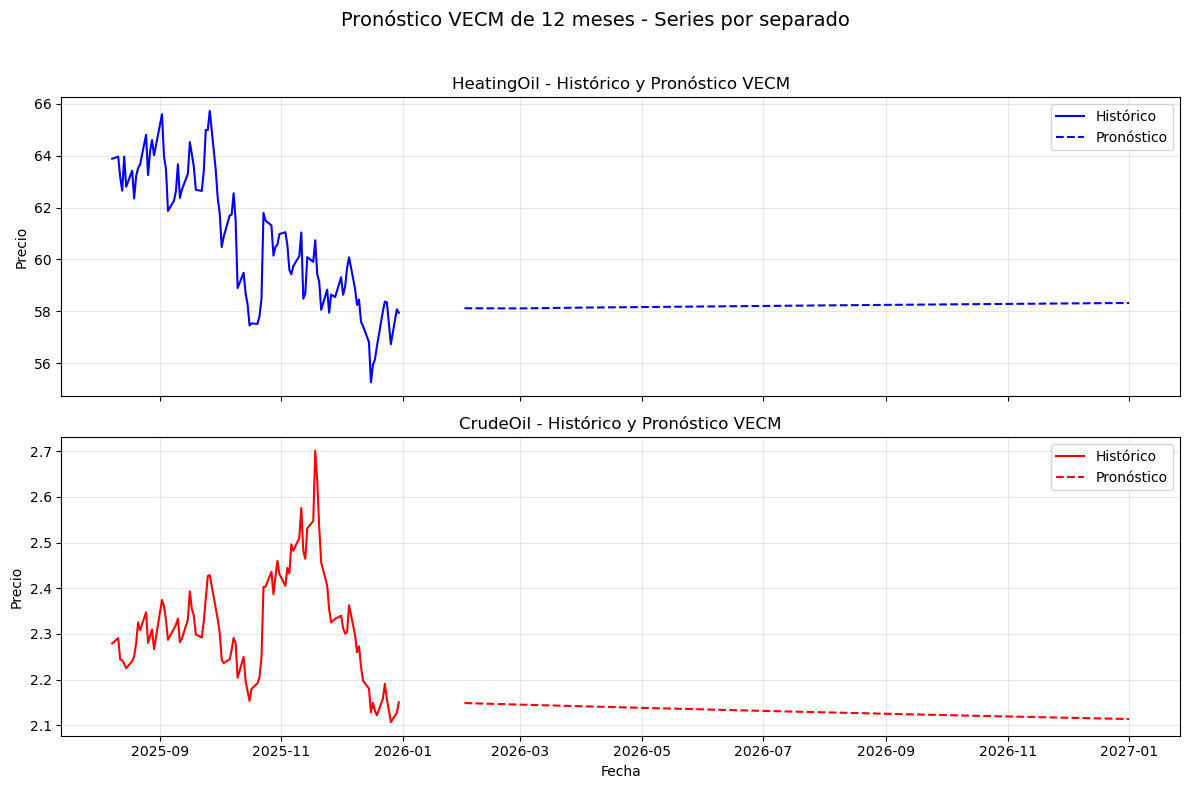

In [9]:
def forecast_vecm(res, df, steps=12):
    try:
        forecast_vals = res.predict(steps=steps)
    except AttributeError:
        forecast_vals = res.forecast(df.values[-res.k_ar_diff:], steps)

    future_idx = pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods=steps, freq='MS')
    forecast_df = pd.DataFrame(forecast_vals, columns=df.columns, index=future_idx)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    ax1.plot(df.index[-100:], df['HeatingOil'][-100:], label='Histórico', color='blue')
    ax1.plot(forecast_df.index, forecast_df['HeatingOil'], label='Pronóstico', color='blue', linestyle='--')
    ax1.set_title('HeatingOil - Histórico y Pronóstico VECM')
    ax1.set_ylabel('Precio')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(df.index[-100:], df['CrudeOil'][-100:], label='Histórico', color='red')
    ax2.plot(forecast_df.index, forecast_df['CrudeOil'], label='Pronóstico', color='red', linestyle='--')
    ax2.set_title('CrudeOil - Histórico y Pronóstico VECM')
    ax2.set_ylabel('Precio')
    ax2.set_xlabel('Fecha')
    ax2.legend()
    ax2.grid(alpha=0.3)

    fig.suptitle('Pronóstico VECM de 12 meses - Series por separado', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

forecast_vecm(vecm_res, df)

c:\Users\wsand\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


   Summary of Regression Results   
Model:                          VAR
Method:                         OLS
Date:           vie, 01, may., 2026
Time:                      18:16:12
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -4.50840
Nobs:                     2763.00    HQIC:                  -4.51662
Log likelihood:          -1588.92    FPE:                  0.0108752
AIC:                     -4.52127    Det(Omega_mle):       0.0108517
--------------------------------------------------------------------
Results for equation HeatingOil
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                 0.002871         0.038907            0.074           0.941
L1.HeatingOil        -0.259216         0.021374          -12.127           0.000
L1.CrudeOil           4.143654         0.752213   

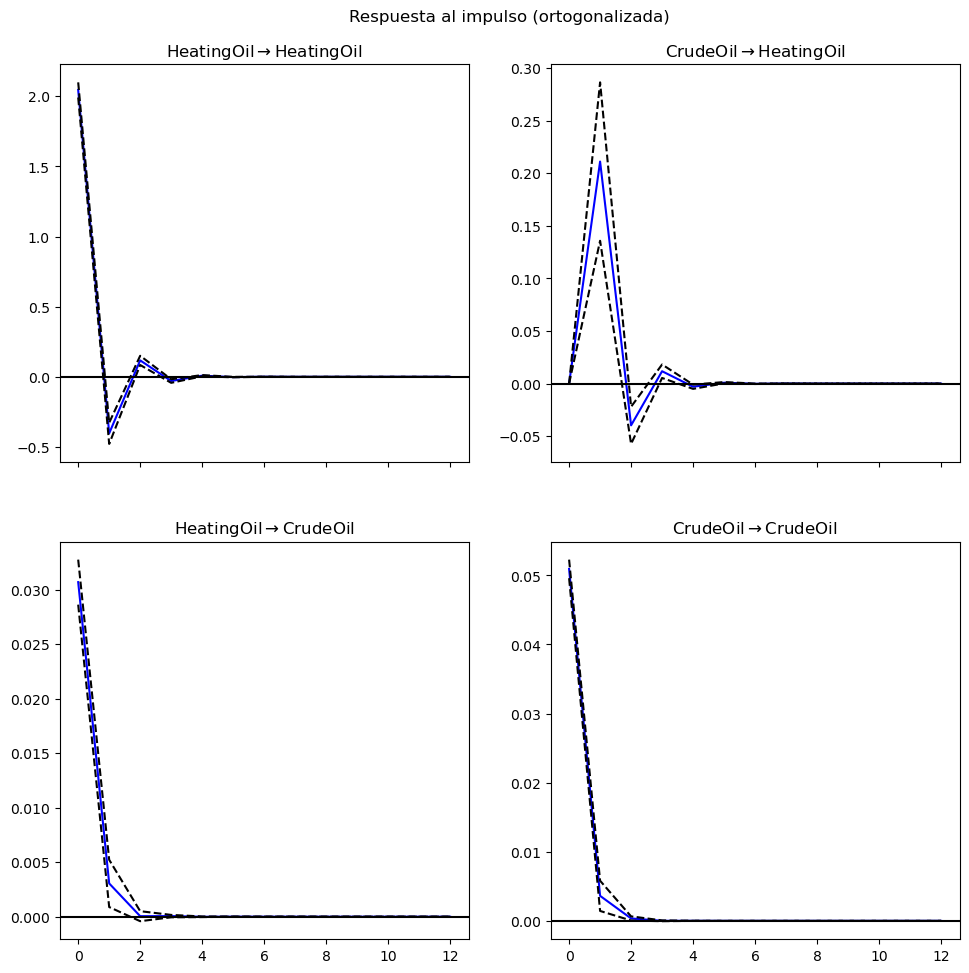

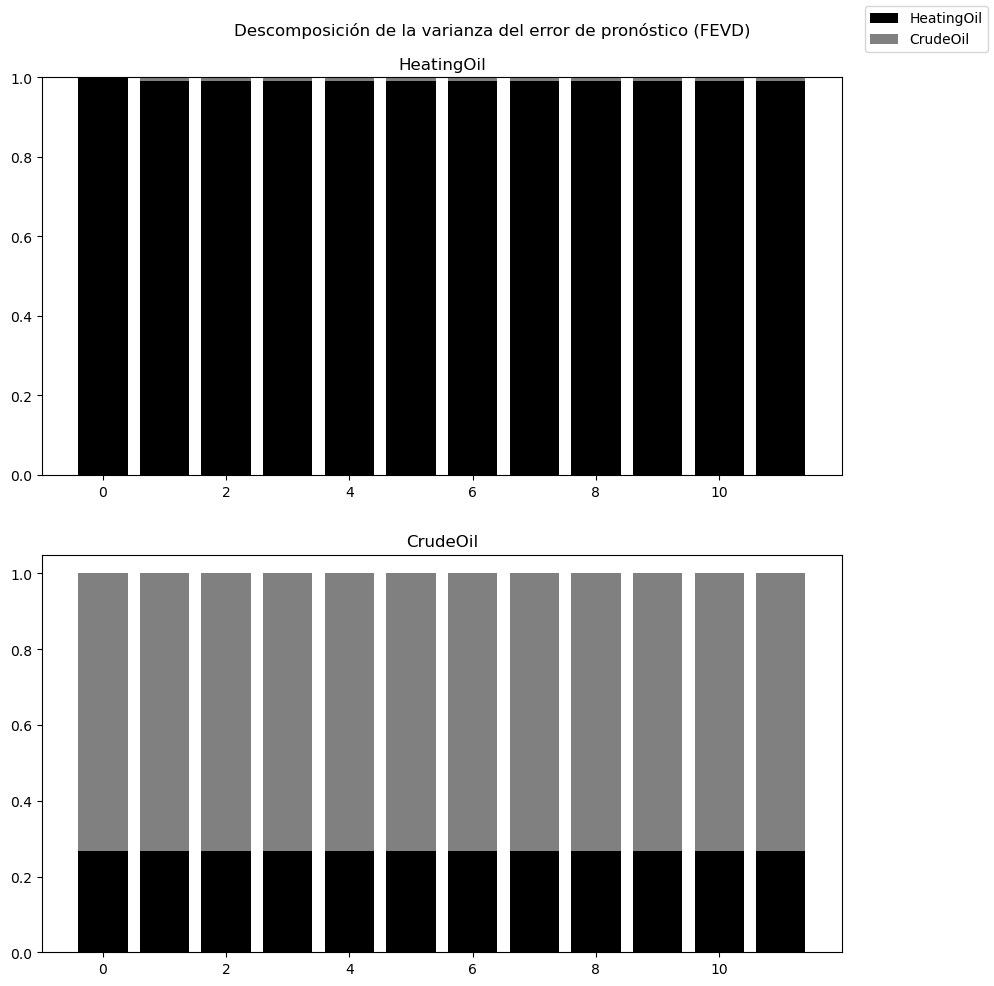

In [11]:
from statsmodels.tsa.api import VAR 


def  run_var_irf_fevd ( df_diff, lags= 1 , horizon= 12 ): 
    model = VAR(df_diff) 
    res = model.fit(maxlags=lags) 
    print (res.summary()) 
    irf = res.irf(horizon) 
    irf.plot(orth= True ) 
    plt.suptitle( "Respuesta al impulso (ortogonalizada)" ) 
    plt.savefig( "var_irf_orthogonalized.png" ) 
    plt.show() 
    fevd = res.fevd(horizon) 
    fevd.plot() 
    plt.suptitle( "Descomposición de la varianza del error de pronóstico (FEVD)" ) 
    plt.savefig( "var_fevd.png" ) 
    plt.show() 
run_var_irf_fevd(df.diff().dropna())